Best parameters found:  {'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}

In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [36]:
df = pd.read_csv("Ready_Data.csv")
df.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight,label
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,412.57,1
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,391.36,0
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,263.38,0
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,247.38,0
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,305.46,0


In [37]:
x = df.drop(["label"],axis=1)
y = df["label"]

In [38]:
with open('feature.pkl', 'rb') as f:
        expected_features = pickle.load(f)

In [39]:
x = pd.DataFrame(x, columns=expected_features)

In [40]:
x.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,0,412.57
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,0,391.36
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,0,263.38
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,0,247.38
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,0,305.46


In [41]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [42]:
model = RandomForestClassifier(criterion='gini', max_depth= 20, max_features= 'sqrt', min_samples_split= 2, n_estimators= 100, random_state=42)

In [43]:
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
print(f"Accuracy while training: {train_accuracy}")
print(f"Accuracy while testing: {test_accuracy}")

Accuracy while training: 0.909689557855127
Accuracy while testing: 0.856203007518797


In [ ]:
y_train_proba = model.predict_proba(x_train)[:, 1]
y_test_proba = model.predict_proba(x_test)[:, 1]

train_roc_auc = roc_auc_score(y_train,y_train_proba)
test_roc_auc = roc_auc_score(y_test,y_test_proba)
print("TRAINING PERFORMANCE:")
print(f"Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"ROC-AUC:  {train_roc_auc:.4f}")

print("\nTEST PERFORMANCE:")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"ROC-AUC:  {test_roc_auc:.4f}")

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred, target_names=['Inactive', 'Active']))


TRAINING PERFORMANCE:
Accuracy: 0.9097 (90.97%)
ROC-AUC:  0.9962

TEST PERFORMANCE:
Accuracy: 0.8562 (85.62%)
ROC-AUC:  0.9279

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Inactive       0.83      0.32      0.46       205
      Active       0.86      0.98      0.92       859

    accuracy                           0.86      1064
   macro avg       0.85      0.65      0.69      1064
weighted avg       0.85      0.86      0.83      1064



In [46]:
cm = confusion_matrix(y_test,y_test_pred)
print(f"Confusion Metrix:\n{cm}")

Confusion Metrix:
[[ 65 140]
 [ 13 846]]


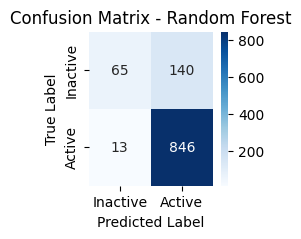

In [47]:
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

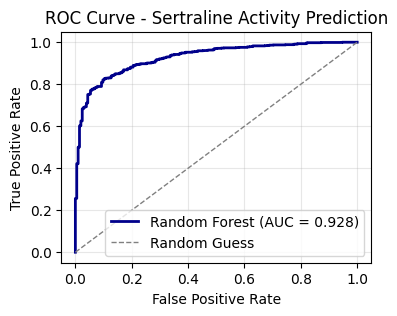

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'Random Forest (AUC = {test_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Sertraline Activity Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [49]:
with open("Random_Forest_Model.pkl","wb") as m:
    pickle.dump(model,m)